# 2026-09-26 hardware 定位复查

第一包前约120秒静止时GNSS水平漂移约5.43m、融合约5.96m；后段连续导航拒收耗尽4096帧IMU历史而重置。第二包启动被GNSS速度判据和ARM状态阻止。原始bag与完整解释见同目录README.md。

## Context & Methods

操作者确认室外开阔地段、开始静止、后续约2m范围移动；第一包前约120s静止。第二包早期解锁只是电机转动。没有外部位置真值，因此测量静止漂移和源一致性，不报告绝对RMSE。按消息粒度保留接收/采集整数纳秒时间；extract.py使用内嵌schema与存在的CRC，核对所有metadata计数。

运行前需同目录两包的CSV.gz（由extract.py从原始MCAP生成）。依赖numpy、pandas、matplotlib；Jupyter需ipykernel。计算代码在analyze.py，初始化与拒收审计分别在audit_initialization.py、gate_audit.py。

In [1]:
from pathlib import Path
import json, runpy
import numpy as np
import pandas as pd
from IPython.display import display, Image
base = Path.cwd()
if not (base / 'analyze.py').exists():
    base = base / 'agi_ros2/analysis/hardware_diagnostic_20260926'
analysis = runpy.run_path(str(base / 'analyze.py'))
paths = sorted(p for p in base.glob('hardware_20260926_*') if p.is_dir())
assert len(paths) == 2
datasets = {p.name.split('_')[2]: analysis['summarize'](p) for p in paths}

## Data

每包全量计数和抽取表均可核对；未初始化的位置零值不是有效测量。

In [2]:
rows = []
for label, (data, summary) in datasets.items():
    manifest = summary['manifest']
    assert manifest['validation']['all_topic_counts_match_metadata']
    fused = data['fused_state']
    assert len(fused) == manifest['topic_counts']['/fused_state']
    rows.append({'bag': label, 'seconds': round(manifest['duration_s'], 3),
                 'all_messages': sum(manifest['topic_counts'].values()),
                 'fused_messages': len(fused), 'initialized_messages': int(fused.initialized.sum())})
display(pd.DataFrame(rows))
second = datasets['162634'][0]['fused_state']
assert not second.initialized.any()
assert (second[['position.x', 'position.y', 'position.z']].to_numpy() == 0).all()

,bag,seconds,all_messages,fused_messages,initialized_messages
0,161859,247.707,531593,123672,112220
1,162634,165.356,278910,82398,0


## Results

第一包静止段：各话题从首次可用位置开始，到bag 120s。起点不同，属于各自静止稳定性，不是同步真值误差。

In [3]:
window = datasets['161859'][1]['windows']['0_120']
rows = []
for name in ['navigation', 'fused']:
    w = window[name]
    rows.append({'source': name, 'samples': w['n'],
                 'max_horizontal_displacement_m': round(w['max_horizontal_distance_from_first_m'], 3),
                 'end_minus_start_z_m': round(w['end_minus_start_xyz_m'][2], 3),
                 'z_span_m': round(w['span_xyz_m'][2], 3)})
display(pd.DataFrame(rows))

,source,samples,max_horizontal_displacement_m,end_minus_start_z_m,z_span_m
0,navigation,1141,5.428,-12.100,12.12
1,fused,57030,5.964,-7.696,7.73


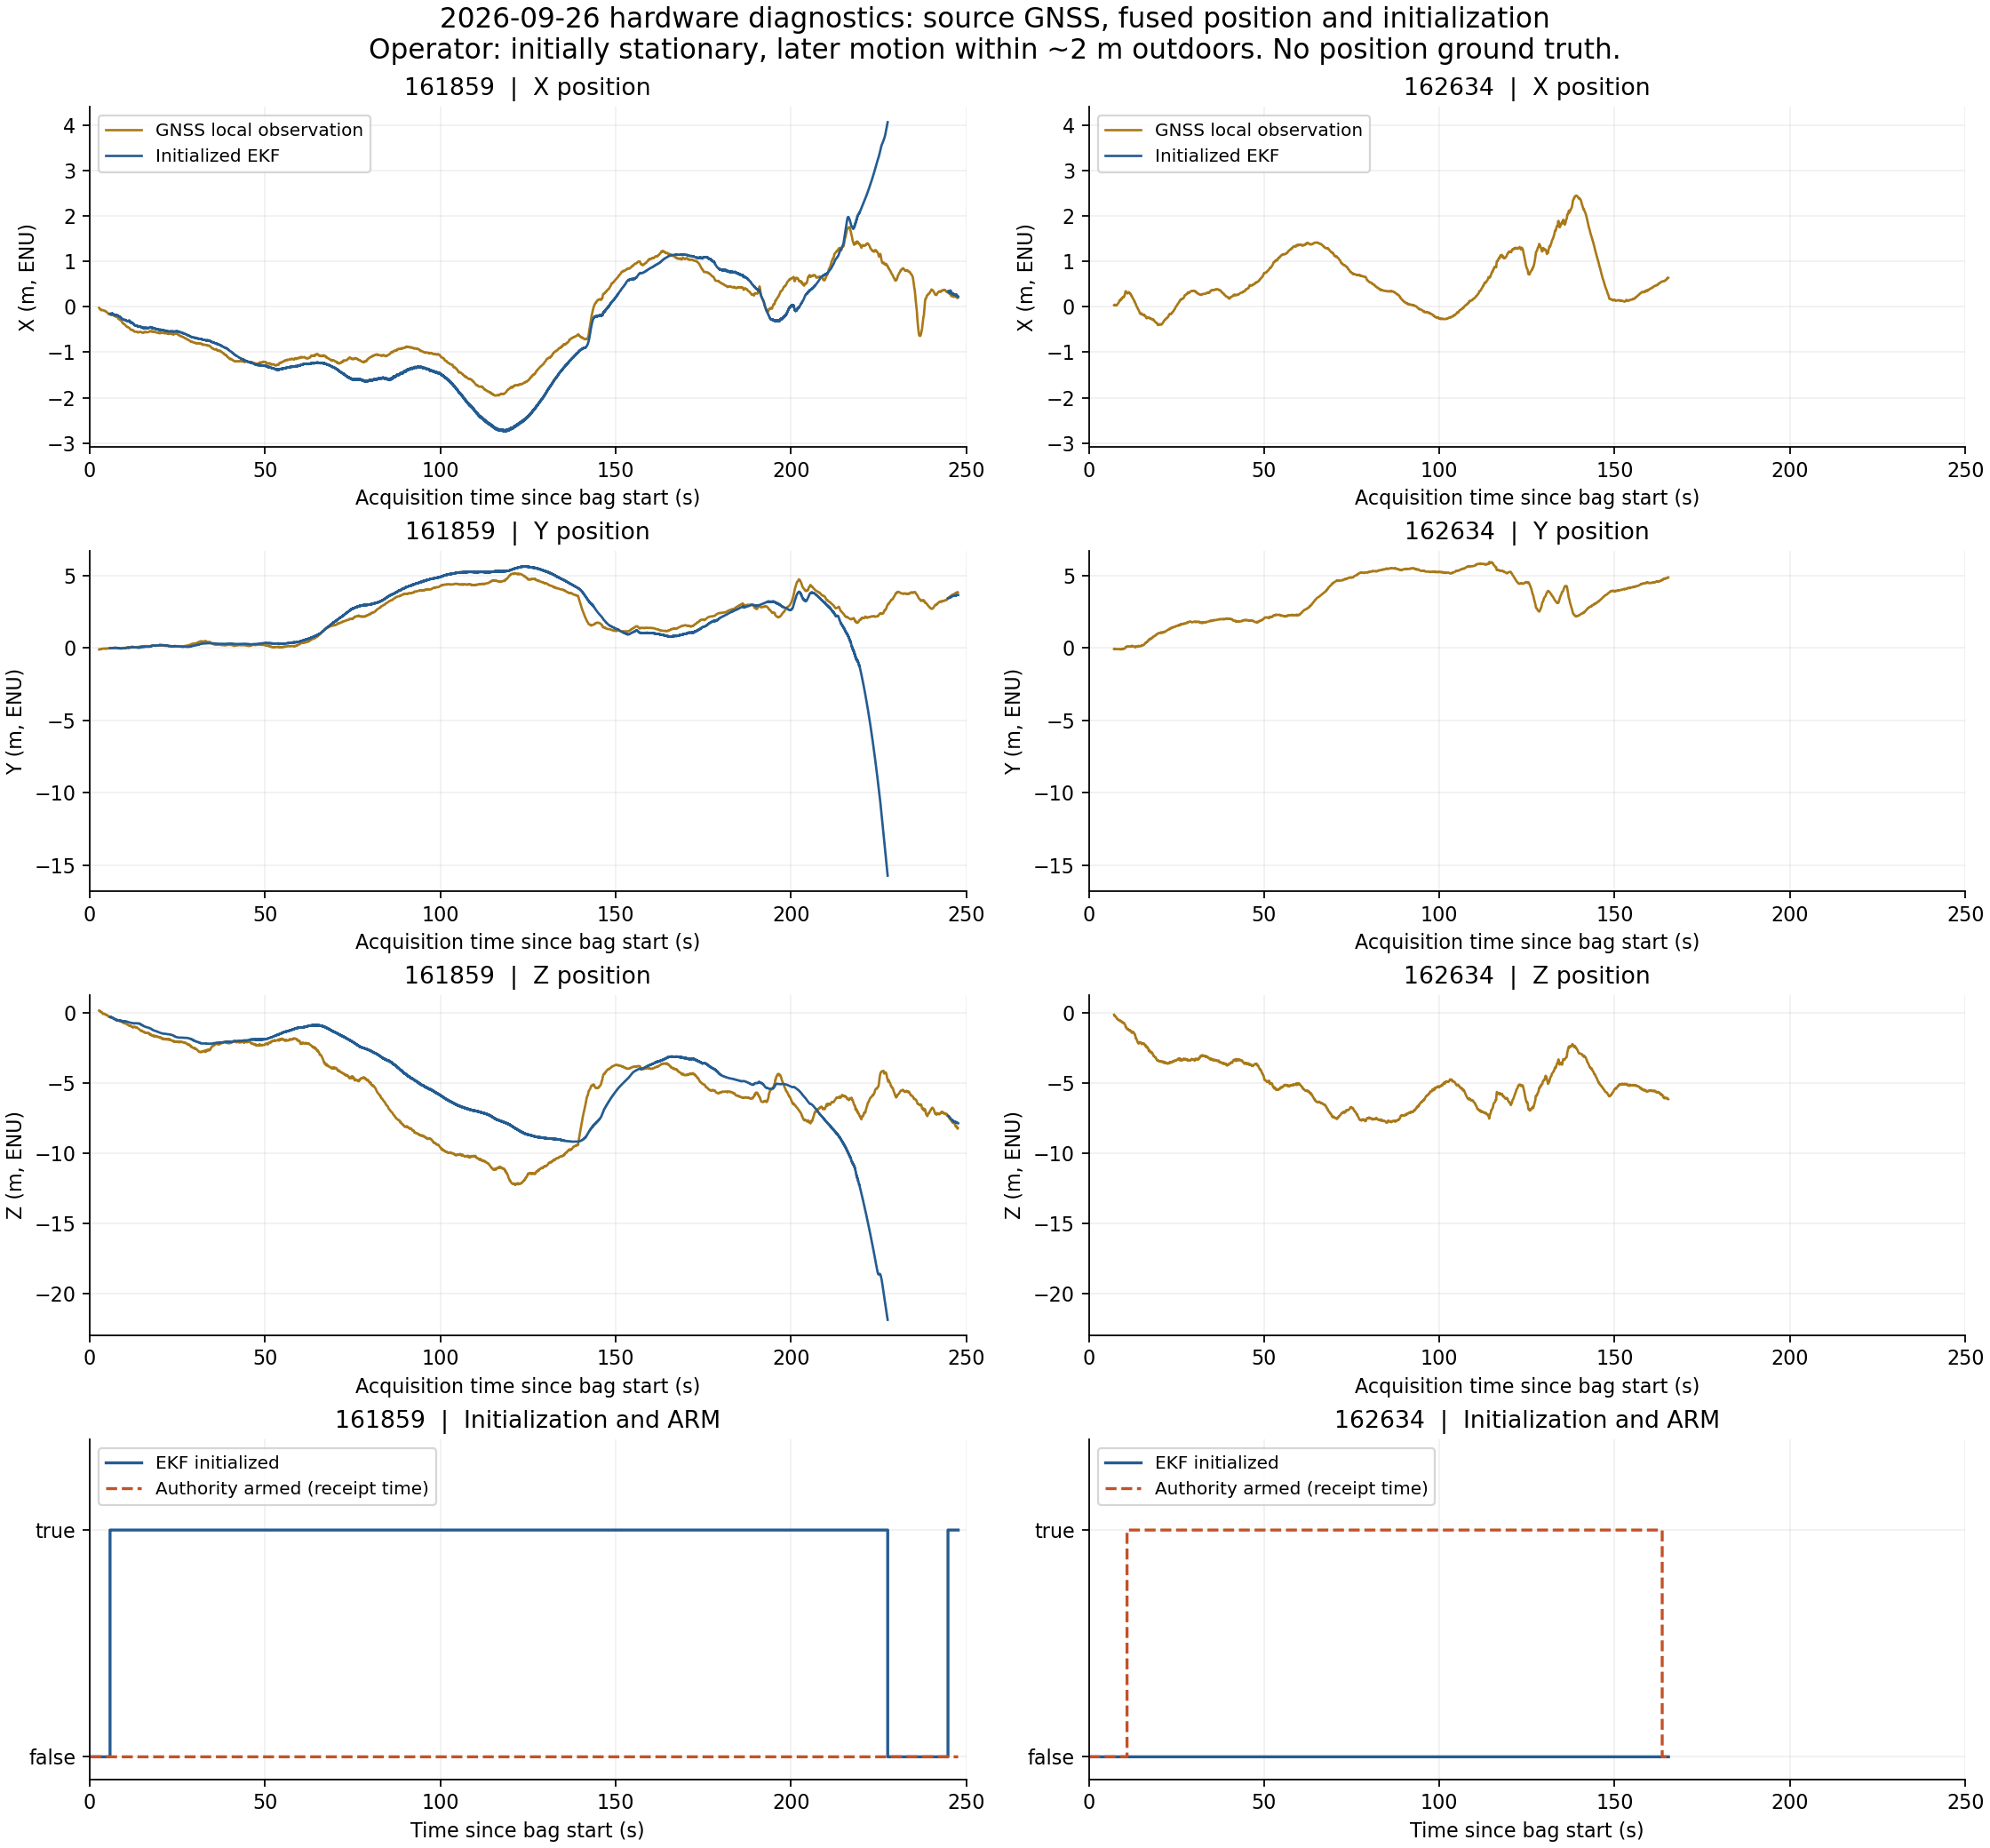

In [4]:
analysis['plot'](datasets)
display(Image(filename=str(base / 'position_and_initialization.png'), width=1000))

图中未初始化的fused位置被隐藏；蓝线中断表示无有效融合状态。GNSS输入与融合共同慢漂移后，第一包在约219–228秒出现额外融合发散；第二包只有GNSS局部观测。

In [5]:
audit = json.loads((base / 'gate_audit.json').read_text())
print('GNSS rejection count before reset:', audit['rejected_updates_before_reset'])
print('Uninterrupted rejections after last accepted update:', audit['uninterrupted_rejections_after_last_accept'])
print('Queue coverage evidence:')
print(json.dumps(audit['queue_coverage'], indent=2))

GNSS rejection count before reset: 65
Uninterrupted rejections after last accepted update: 59
Queue coverage evidence:
{
  "max_queue_size": 4096,
  "last_posterior_ns": 1790410960604088832,
  "reset_imu_stamp_ns": 1790410968806469888,
  "elapsed_source_s": 8.202381056,
  "imu_samples_strictly_after_posterior_through_reset": 4096,
  "fused_callbacks_strictly_after_posterior_through_reset": 4096,
  "source_evidence": [
    "agilib/include/agilib/estimator/ekf_imu/ekf_imu.hpp:100",
    "agilib/src/estimator/ekf_imu/ekf_imu.cpp:128-159",
    "agilib/src/estimator/ekf_imu/ekf_imu.cpp:212-216",
    "agilib/src/estimator/ekf_imu/ekf_imu.cpp:383-388",
    "agi_ros2/src/state_fusion_node.cpp:324-327"
  ]
}


## Takeaways

先确保未解锁时initialized/imu_ready/navigation_valid成立，再开始后续操作。当前单帧GNSS速度超过0.3m/s会清空3秒窗口，即便机体静止；ARM状态本身随后阻止初始化。第一包静止GNSS高度大幅变化需单独核查定位源，IMU静止重力残差需标定排查，连续拒收和历史缓存边界需另行处理。完整时序、参数含义、证据限制及源码位置见README.md。